In [20]:
#https://judge.nitro-ai.org/competitions/ceoai/ceoai-2026-day-1/4/submissions?author=umirzoq&page=1&page_size=10
import numpy as np
import pandas as pd
import os 
from PIL import Image
import torch 
from torch import nn
import base64
import io
import matplotlib.pyplot as plt

In [13]:
test = pd.read_csv("/kaggle/input/datasets/umirzoq001/euroai-ceoai-2026-day-1-textsnap/test_data (3).csv")

In [14]:
test

,datapointID,imageBase64
0,test01,iVBORw0KGgoAAAANSUhEUgAAAQAAAACACAIAAABr1yBdAA...
1,test02,iVBORw0KGgoAAAANSUhEUgAAAQAAAACACAIAAABr1yBdAA...
2,test03,iVBORw0KGgoAAAANSUhEUgAAAQAAAACACAIAAABr1yBdAA...
3,test04,iVBORw0KGgoAAAANSUhEUgAAAQAAAACACAIAAABr1yBdAA...
4,test05,iVBORw0KGgoAAAANSUhEUgAAAQAAAACACAIAAABr1yBdAA...
...,...,...
936,test937,iVBORw0KGgoAAAANSUhEUgAAAQAAAACACAIAAABr1yBdAA...
937,test938,iVBORw0KGgoAAAANSUhEUgAAAQAAAACACAIAAABr1yBdAA...
938,test939,iVBORw0KGgoAAAANSUhEUgAAAQAAAACACAIAAABr1yBdAA...
939,test940,iVBORw0KGgoAAAANSUhEUgAAAQAAAACACAIAAABr1yBdAA...


In [15]:
test.dtypes

datapointID    object
imageBase64    object
dtype: object

In [16]:
def image(image_base64):
    image_data = base64.b64decode(image_base64)
    image = Image.open(io.BytesIO(image_data))
    image_array = np.array(image)
    
    return image_array


In [77]:
image_array = image(test.iloc[51, 1])

In [78]:
image_array.shape

(128, 256, 3)

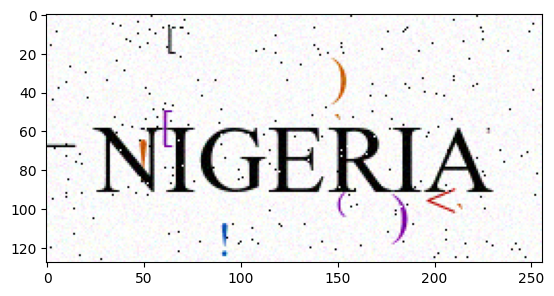

In [79]:
plt.imshow(image_array)

In [99]:
import glob
import random
import string
import numpy as np
from PIL import Image, ImageDraw, ImageFont

SERIF = (glob.glob("/usr/share/fonts/**/DejaVuSerif.ttf", recursive=True)
         or glob.glob("/usr/share/fonts/**/*Serif*.ttf", recursive=True)
         or glob.glob("/usr/share/fonts/**/*.ttf", recursive=True))[0]

def _rand_color(dark=True):
    c = [random.randint(0, 200) for _ in range(3)]
    if dark:
        c[random.randint(0, 2)] = random.randint(0, 100)
    return tuple(c)

def make_sample(w=256, h=128, n_clutter=12, n_dots=60):
    chars = string.ascii_uppercase + string.digits
    for _ in range(100):
        lines = []
        for _ in range(random.randint(1, 2)):
            n = random.randint(1, 8)
            line = random.choice(chars)
            for _ in range(n - 1):
                if random.random() < 0.15:
                    line += " "
                line += random.choice(chars)
            lines.append(line)
        size = random.randint(10, 50)
        font = ImageFont.truetype(SERIF, size)
        img = Image.new("RGB", (w, h), (255, 255, 255))
        draw = ImageDraw.Draw(img)
        gap = max(2, size // 3)
        boxes = [draw.textbbox((0, 0), l, font=font) for l in lines]
        ws = [b[2] - b[0] for b in boxes]
        hs = [b[3] - b[1] for b in boxes]
        total_h = sum(hs) + gap * (len(lines) - 1)
        if max(ws) > w - 4 or total_h > h - 4:
            continue
        text_color = _rand_color()
        y = random.randint(2, h - total_h - 2)
        for line, b, lw, lh in zip(lines, boxes, ws, hs):
            x = random.randint(2, w - lw - 2)
            draw.text((x - b[0], y - b[1]), line, font=font, fill=text_color)
            y += lh + gap
        for _ in range(n_clutter):
            kind = random.random()
            col = _rand_color()
            if kind < 0.6:
                c = random.choice("*.,'-:;+`\"!?{}()[]\\/|")
                s = random.randint(8, 18)
                f = ImageFont.truetype(SERIF, s)
                draw.text((random.randint(0, w - s), random.randint(0, h - s)), c, font=f, fill=col)
            elif kind < 0.85:
                x1, y1 = random.randint(0, w - 20), random.randint(0, h - 20)
                x2, y2 = x1 + random.randint(-15, 15), y1 + random.randint(-15, 15)
                draw.line([x1, y1, x2, y2], fill=col, width=random.randint(1, 2))
            else:
                x1, y1 = random.randint(0, w - 12), random.randint(0, h - 12)
                r = random.randint(2, 5)
                if random.random() < 0.5:
                    draw.ellipse([x1, y1, x1 + r, y1 + r], fill=col)
                else:
                    draw.rectangle([x1, y1, x1 + r * 2, y1 + r * 2], outline=col)
        for _ in range(n_dots):
            x1, y1 = random.randint(0, w - 2), random.randint(0, h - 2)
            g = random.randint(0, 80)
            draw.point((x1, y1), fill=(g, g, g))
        arr = np.array(img, dtype=np.float32)
        arr += np.random.normal(0, random.uniform(2, 6), arr.shape)
        arr = np.clip(arr, 0, 255).astype(np.uint8)
        text = "_".join(l.replace(" ", "_") for l in lines)
        return arr, text
    raise RuntimeError("text never fit")

In [119]:
img, text = make_sample()

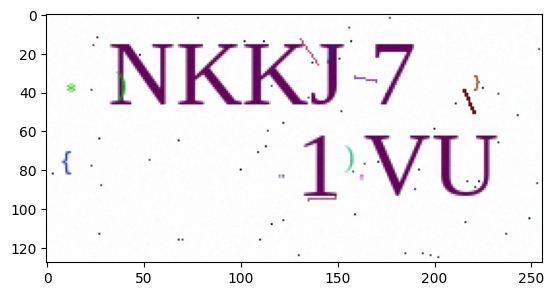

In [120]:
plt.imshow(img)

In [121]:

import glob
import random
import string

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw, ImageFont
from torch.utils.data import DataLoader, Dataset

CHARSET = string.ascii_uppercase + string.digits + "_"   # 37 classes
BLANK = 0                                                # CTC blank index
IDX = {c: i + 1 for i, c in enumerate(CHARSET)}          # 1..37
REV = {i + 1: c for i, c in enumerate(CHARSET)}
N_CLASSES = len(CHARSET) + 1

LINE_H, LINE_W = 32, 256

SERIF = (glob.glob("/usr/share/fonts/**/DejaVuSerif.ttf", recursive=True)
         or glob.glob("/usr/share/fonts/**/*Serif*.ttf", recursive=True)
         or glob.glob("/usr/share/fonts/**/*.ttf", recursive=True))[0]

def _rand_color():
    c = [random.randint(0, 200) for _ in range(3)]
    c[random.randint(0, 2)] = random.randint(0, 100)
    return tuple(c)


def make_line_sample(w=256, h=64, n_clutter=6, n_dots=30):
    chars = string.ascii_uppercase + string.digits
    for _ in range(100):
        n = random.randint(1, 8)
        line = random.choice(chars)
        for _ in range(n - 1):
            if random.random() < 0.15:
                line += " "
            line += random.choice(chars)
        size = random.randint(10, 50)
        font = ImageFont.truetype(SERIF, size)
        img = Image.new("RGB", (w, h), (255, 255, 255))
        draw = ImageDraw.Draw(img)
        b = draw.textbbox((0, 0), line, font=font)
        lw, lh = b[2] - b[0], b[3] - b[1]
        if lw > w - 4 or lh > h - 4:
            continue
        color = _rand_color()
        x = random.randint(2, w - lw - 2)
        y = random.randint(2, h - lh - 2)
        draw.text((x - b[0], y - b[1]), line, font=font, fill=color)
        for _ in range(n_clutter):
            col = _rand_color()
            r = random.random()
            if r < 0.6:
                c = random.choice("*.,'-:;+`\"!?{}()[]\\/|")
                s = random.randint(8, 18)
                f = ImageFont.truetype(SERIF, s)
                draw.text((random.randint(0, w - s), random.randint(0, h - s)),
                          c, font=f, fill=col)
            elif r < 0.85:
                x1, y1 = random.randint(0, w - 20), random.randint(0, h - 20)
                draw.line([x1, y1, x1 + random.randint(-15, 15),
                           y1 + random.randint(-15, 15)],
                          fill=col, width=random.randint(1, 2))
            else:
                x1, y1 = random.randint(0, w - 12), random.randint(0, h - 12)
                rr = random.randint(2, 5)
                draw.ellipse([x1, y1, x1 + rr, y1 + rr], fill=col)
        for _ in range(n_dots):
            g = random.randint(0, 80)
            draw.point((random.randint(0, w - 2), random.randint(0, h - 2)),
                       fill=(g, g, g))
        arr = np.array(img, dtype=np.float32)
        arr += np.random.normal(0, random.uniform(2, 6), arr.shape)
        arr = np.clip(arr, 0, 255).astype(np.uint8)
        return arr, line.replace(" ", "_")
    raise RuntimeError("text never fit")


def ink_mask(rgb):
    """Binary mask of pixels belonging to the main text color."""
    arr = rgb.astype(np.int16)
    gray = arr.mean(axis=2)
    dark = gray < 180
    if dark.sum() < 10:
        return dark
    colors = arr[dark]
    med = np.median(colors, axis=0)
    dist = np.abs(arr - med).sum(axis=2)
    return (dist < 120) & dark


def to_net_input(rgb, h=LINE_H, w=LINE_W):
    """RGB line crop -> normalized (1, h, w) float tensor content."""
    mask = ink_mask(rgb).astype(np.float32)
    ys, xs = np.nonzero(mask)
    if len(xs) > 0:
        y0, y1 = max(ys.min() - 2, 0), min(ys.max() + 3, mask.shape[0])
        x0, x1 = max(xs.min() - 2, 0), min(xs.max() + 3, mask.shape[1])
        mask = mask[y0:y1, x0:x1]
    img = Image.fromarray((mask * 255).astype(np.uint8))
    scale = h / img.height
    new_w = max(1, min(w, int(img.width * scale)))
    img = img.resize((new_w, h), Image.BILINEAR)
    out = np.zeros((h, w), dtype=np.float32)
    out[:, :new_w] = np.asarray(img, dtype=np.float32) / 255.0
    return out[None]


class SynthLines(Dataset):
    def __init__(self, epoch_size=5000):
        self.epoch_size = epoch_size

    def __len__(self):
        return self.epoch_size

    def __getitem__(self, _):
        rgb, text = make_line_sample()
        x = torch.from_numpy(to_net_input(rgb))
        y = torch.tensor([IDX[c] for c in text], dtype=torch.long)
        return x, y


def collate(batch):
    xs, ys = zip(*batch)
    x = torch.stack(xs)
    y_lens = torch.tensor([len(y) for y in ys], dtype=torch.long)
    y = torch.cat(ys)
    return x, y, y_lens


class CRNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),                       # 32x16x128
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),                       # 64x8x64
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2, 1)),                     # 128x4x64
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2, 1)),                     # 128x2x64
        )
        self.rnn = nn.LSTM(128 * 2, 128, num_layers=2,
                           bidirectional=True, batch_first=True)
        self.fc = nn.Linear(256, n_classes)

    def forward(self, x):                    
        f = self.cnn(x)                         
        b, c, h, w = f.shape
        f = f.permute(0, 3, 1, 2).reshape(b, w, c * h)
        f, _ = self.rnn(f)
        return self.fc(f) 


def greedy_decode(logits):
    """logits: (B, T, C) -> list of strings (CTC collapse)."""
    out = []
    for seq in logits.argmax(-1).cpu().numpy():
        chars, prev = [], BLANK
        for k in seq:
            if k != BLANK and k != prev:
                chars.append(REV[k])
            prev = k
        out.append("".join(chars))
    return out


def levenshtein(a, b):
    if len(a) < len(b):
        a, b = b, a
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[j - 1] + 1,
                           prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]


def train(epochs=15, epoch_size=5000, batch_size=64, lr=1e-3,
          device=None, out_path="crnn.pt"):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = CRNN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ctc = nn.CTCLoss(blank=BLANK, zero_infinity=True)

    loader = DataLoader(SynthLines(epoch_size), batch_size=batch_size,
                        collate_fn=collate, num_workers=2)
    val = [make_line_sample() for _ in range(200)]

    for ep in range(1, epochs + 1):
        model.train()
        total = 0.0
        for x, y, y_lens in loader:
            x, y, y_lens = x.to(device), y.to(device), y_lens.to(device)
            logits = model(x)                               # (B,T,C)
            log_probs = F.log_softmax(logits, dim=-1).permute(1, 0, 2)
            in_lens = torch.full((x.size(0),), logits.size(1),
                                 dtype=torch.long, device=device)
            loss = ctc(log_probs, y, in_lens, y_lens)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            total += loss.item() * x.size(0)
        sched.step()

        model.eval()
        sim, exact = 0.0, 0
        with torch.no_grad():
            for rgb, gt in val:
                x = torch.from_numpy(to_net_input(rgb))[None].to(device)
                pred = greedy_decode(model(x))[0]
                d = levenshtein(pred, gt)
                sim += 1 - d / max(len(pred), len(gt), 1)
                exact += (pred == gt)
        print(f"epoch {ep:2d}  loss {total/epoch_size:.4f}  "
              f"val LevSim {sim/len(val):.3f}  exact {exact/len(val):.3f}")
        torch.save(model.state_dict(), out_path)
    return model


def split_lines(rgb):
    """Return list of line crops (1 or 2) in reading order."""
    mask = ink_mask(rgb)
    rows = mask.sum(axis=1)
    thr = max(2, 0.05 * rows.max())
    active = rows > thr
    bands, start = [], None
    for i, a in enumerate(active):
        if a and start is None:
            start = i
        elif not a and start is not None:
            bands.append((start, i))
            start = None
    if start is not None:
        bands.append((start, len(active)))
    bands = [b for b in bands if b[1] - b[0] >= 4]
    if not bands:
        return [rgb]
    merged = [bands[0]]
    for s, e in bands[1:]:
        if s - merged[-1][1] < 3:
            merged[-1] = (merged[-1][0], e)
        else:
            merged.append((s, e))
    merged.sort(key=lambda b: b[1] - b[0], reverse=True)
    merged = sorted(merged[:2])
    pad = 3
    return [rgb[max(s - pad, 0):min(e + pad, rgb.shape[0])] for s, e in merged]


class Solution:
    def __init__(self, weights="crnn.pt", device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = CRNN().to(self.device)
        self.model.load_state_dict(torch.load(weights, map_location=self.device))
        self.model.eval()

    def predict(self, img: np.ndarray) -> tuple:
        parts = []
        with torch.no_grad():
            for crop in split_lines(img):
                x = torch.from_numpy(to_net_input(crop))[None].to(self.device)
                parts.append(greedy_decode(self.model(x))[0])
        text = "_".join(p for p in parts if p) or "A"
        text = text.strip("_") or "A"
        types = "".join("N" if c.isdigit() else "_" if c == "_" else "L"
                        for c in text)
        return len(text), types, text


if __name__ == "__main__":
    train()

epoch  1  loss 6.8989  val LevSim 0.000  exact 0.000
epoch  2  loss 4.0215  val LevSim 0.000  exact 0.000
epoch  3  loss 3.8825  val LevSim 0.000  exact 0.000
epoch  4  loss 3.7446  val LevSim 0.078  exact 0.000
epoch  5  loss 3.5561  val LevSim 0.079  exact 0.005
epoch  6  loss 3.2538  val LevSim 0.210  exact 0.010
epoch  7  loss 2.8861  val LevSim 0.295  exact 0.005
epoch  8  loss 2.5801  val LevSim 0.320  exact 0.015
epoch  9  loss 2.3745  val LevSim 0.447  exact 0.015
epoch 10  loss 2.1622  val LevSim 0.513  exact 0.015
epoch 11  loss 2.0617  val LevSim 0.529  exact 0.010
epoch 12  loss 1.9977  val LevSim 0.551  exact 0.015
epoch 13  loss 1.9526  val LevSim 0.540  exact 0.025
epoch 14  loss 1.9273  val LevSim 0.564  exact 0.035
epoch 15  loss 1.9192  val LevSim 0.565  exact 0.030


In [124]:
import base64
import io
import csv
import pandas as pd
import numpy as np
from PIL import Image

test_df = test
sol = Solution("crnn.pt")

rows = []
for _, r in test_df.iterrows():
    img = Image.open(io.BytesIO(base64.b64decode(r["imageBase64"]))).convert("RGB")
    arr = np.array(img)
    s1, s2, s3 = sol.predict(arr)
    rows.append((1, r["datapointID"], s1))
    rows.append((2, r["datapointID"], s2))
    rows.append((3, r["datapointID"], s3))

rows.sort(key=lambda x: (x[0], x[1]))

with open("submission.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["subtaskID", "datapointID", "answer"])
    w.writerows(rows)

print(f"wrote {len(rows)} rows for {len(test_df)} images")


wrote 2823 rows for 941 images
